# Báo cáo Thực hành LAB ICN - Module 04 Độc lập
**NOTE:** SIMULATED DATA - NOT REAL NETWORK IDS PERFORMANCE

# GD1: CHUẨN BỊ MÔI TRƯỜNG VÀ DỮ LIỆU

## Mục 4. Bước 1 - Tạo môi trường và cấu trúc dự án
#### *Đã thiết lập môi trường ảo (.venv), xây dựng cấu trúc dự án độc lập và cài đặt các thư viện thành công trên VS Code*
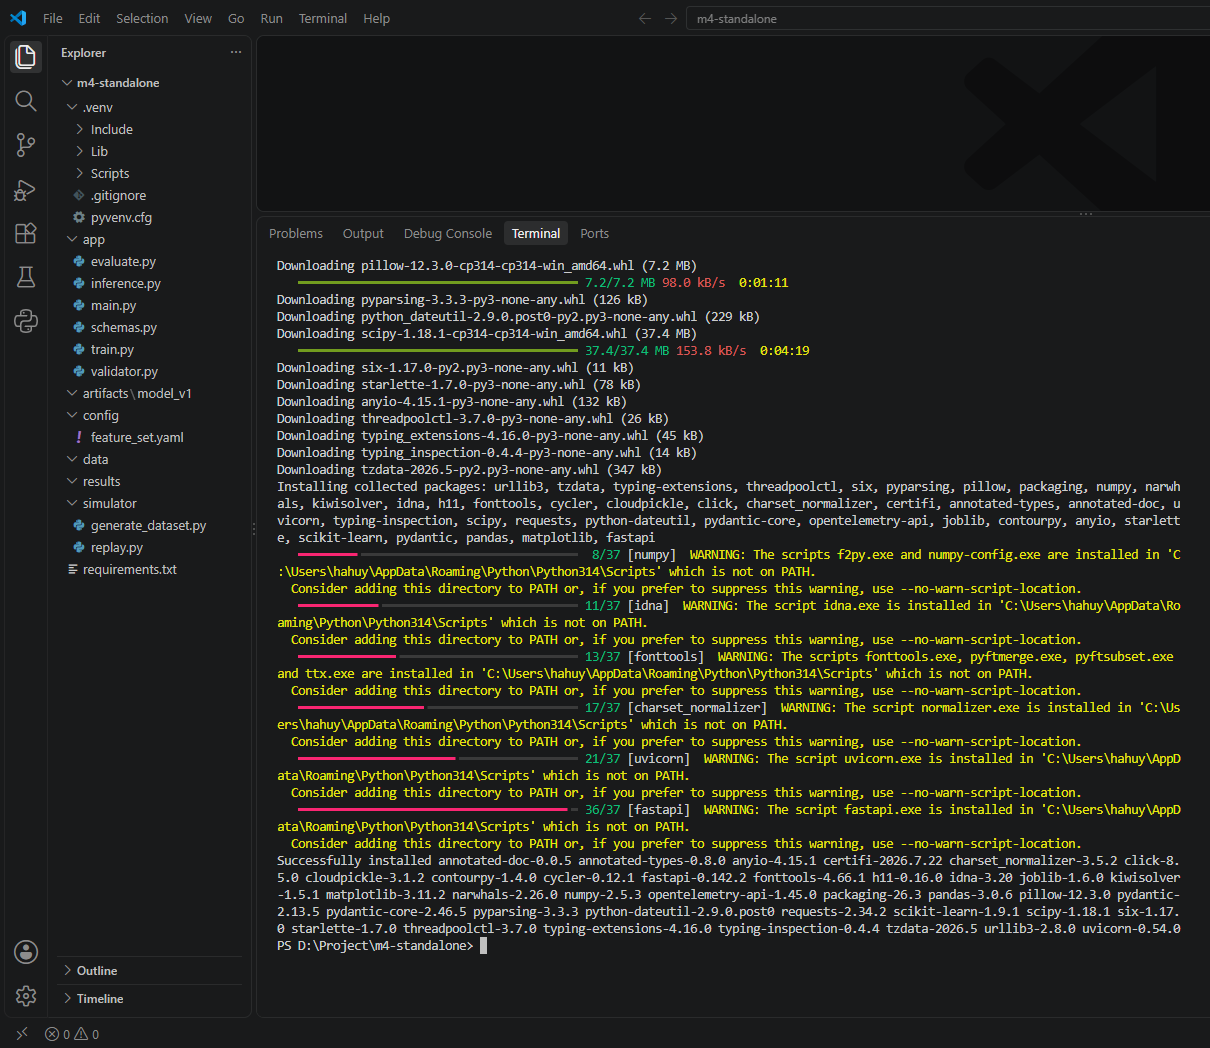

## Mục 5. Bước 2 - Tạo khóa FeatureSet trong config

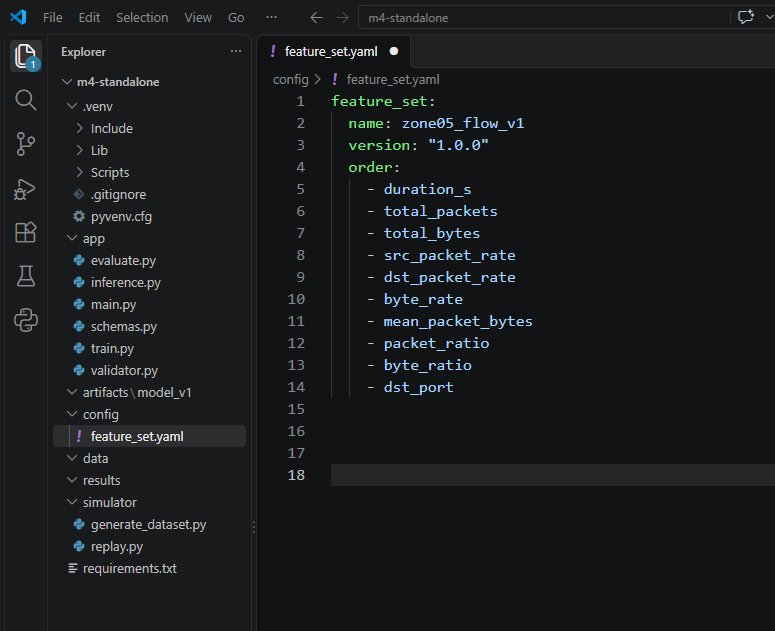

## Mục 6. Bước 3 - Sinh dataset mô phỏng có tham số
#### Sinh data chứa các thuộc tính:
-	Thời gian kéo dài của luồng mạng (s)
-	Tổng số lượng gói tin được truyền trong luồng mạng
-	Tổng dung lượng dữ liệu của luồng mạng (byte)
-	Tốc độ truyền các gói từ địa chỉ nguồn (packet//s)
-	Tốc độ truyền tải dung lượng dữ liệu (byte/s)
-	Dung lượng trung bình của mỗi gói tin trong luồng (byte/packet)
-	Tỷ lệ thống kê của số lượng gói tin và dung lượng byte
-	Cổng đích của mạng
-	Nhãn phân loại (SIM_ATTACK/ NORMAL)
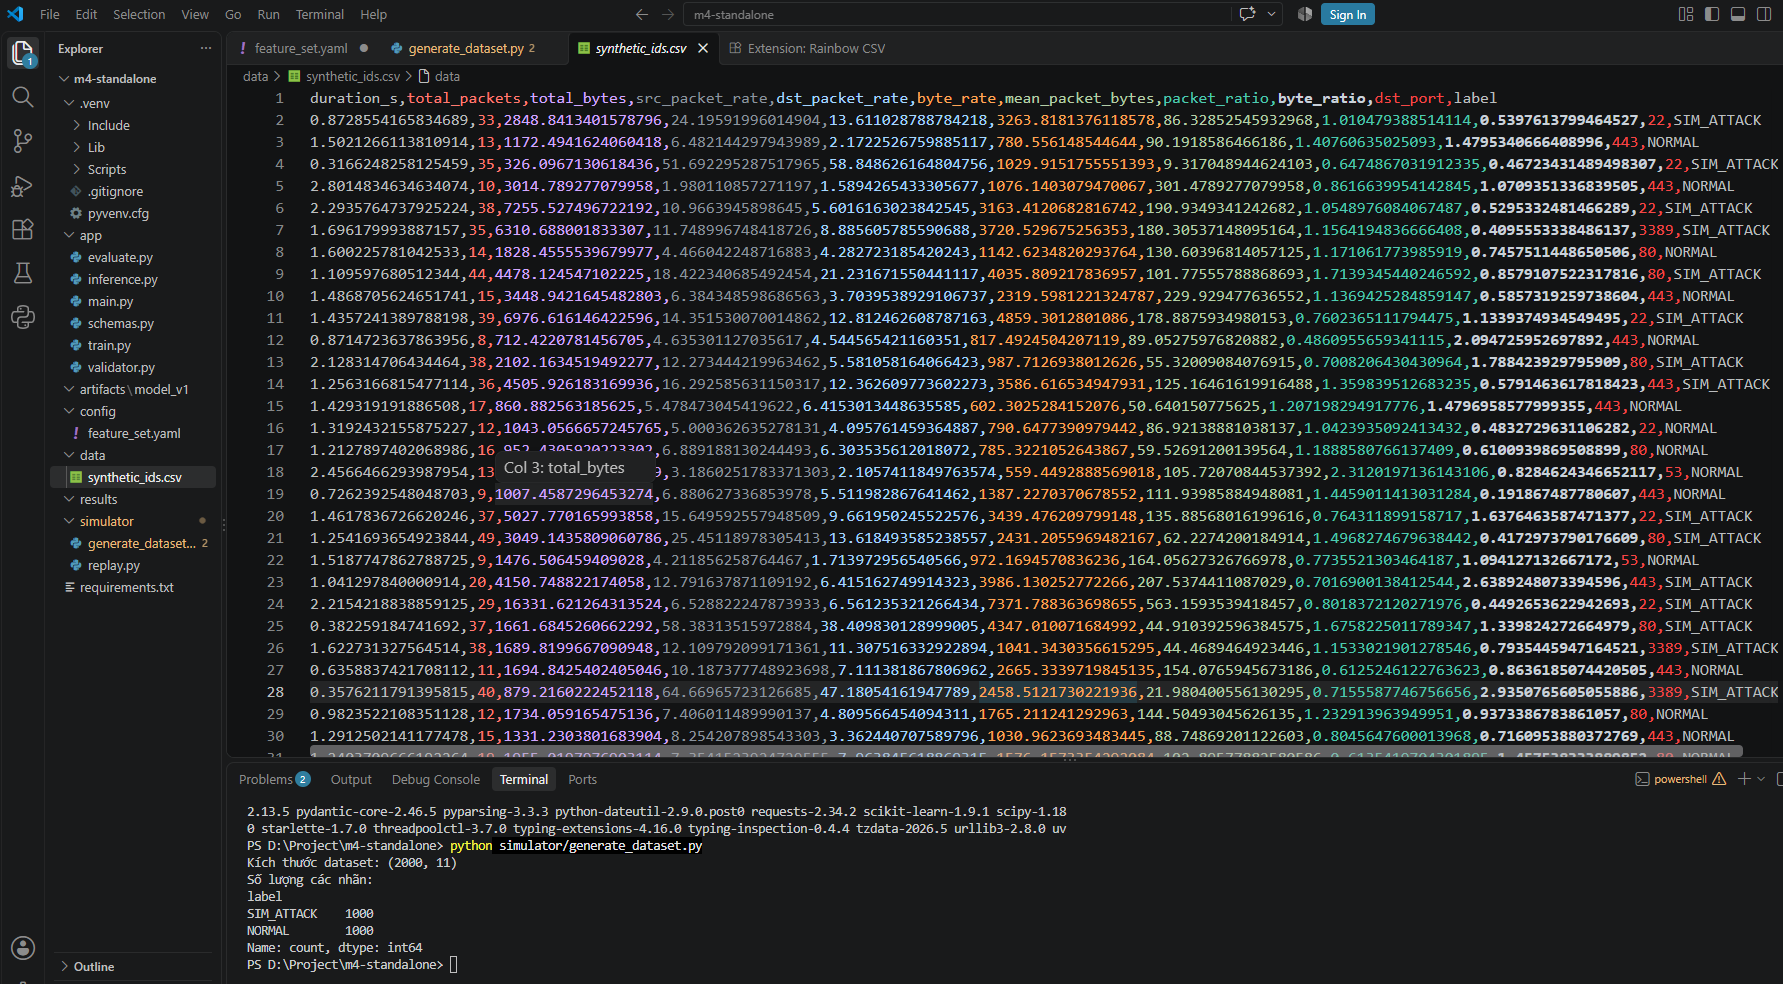

## Mục 7. Lab 4.1. Kiểm tra dataset và phân bố feature
#### Upload file synthetic_ids.csv vừa tạo ở bước trước.
#### Nhận xét:


*  Bộ dữ liệu hoàn chỉnh, không bị thiết sót dữ liệu hay chứa giá trị rỗng. Được chia đều 1000 mẫu SIM_ATTACK và 1000 mẫu NORMAL
*  Mảng số liệu cho thấy sự khác biệt về các giá trị mean, std, max/ min giữa 2 nhãn NORMAL và SIM_ATTACK. Ví dụ:
   *  Số lượng gói tin tủng bình (mean của total_packets) đối với luồng NORMAL chỉ 12.8, trong khi đối với luồng SIM_ATTACK lên tới 36.039.
   * Cổng đích trung bình (mean của dst_port) của luồng NORMAL chủ yếu loanh quanh mốc 237 (gần cổng 80, 443), trong khi luồng SIM_ATTACK có xu hướng rải rác ở các cổng cao hơn (mean là 964).

* Hai biểu đồ Histogram trực quan hóa sự phân bố tần suất của 2 đặc trưng là tổng số gói tin (total_packets) và tốc độ truyền tài byte (byte_rate).
  * Phân bố total_packets: Có thể thấy rõ hai cụm phân bố tách biệt rõ rệt. NORMAL tập trung hẹp ở mức số lượng gói tin thấp (khoảng 10-15 gói). Trong khi đó, cụm màu đỏ (SIM_ATTACK) trải dài và tập trung nhiều ở mức cao (khoảng từ 30 đến gần 50 gói).
  * Phân bố byte_rate: Tương tự, tốc độ truyền tải byte của luồng tấn công mô phỏng (màu đỏ) cao hơn hẳn và có đuôi kéo dài đến tận mức 14000 byte/s, trong khi luồng bình thường (màu xanh) chỉ tập trung rất hẹp ở dưới mức 2000 byte/s






--- BƯỚC 1: THÔNG TIN DỮ LIỆU ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   duration_s         2000 non-null   float64
 1   total_packets      2000 non-null   int64  
 2   total_bytes        2000 non-null   float64
 3   src_packet_rate    2000 non-null   float64
 4   dst_packet_rate    2000 non-null   float64
 5   byte_rate          2000 non-null   float64
 6   mean_packet_bytes  2000 non-null   float64
 7   packet_ratio       2000 non-null   float64
 8   byte_ratio         2000 non-null   float64
 9   dst_port           2000 non-null   int64  
 10  label              2000 non-null   object 
dtypes: float64(8), int64(2), object(1)
memory usage: 172.0+ KB
None

--- BƯỚC 2: SỐ MẪU MỖI LỚP ---
label
SIM_ATTACK    1000
NORMAL        1000
Name: count, dtype: int64

--- BƯỚC 3: THỐNG KÊ MÔ TẢ (SIMULATED DATA) ---
           dura

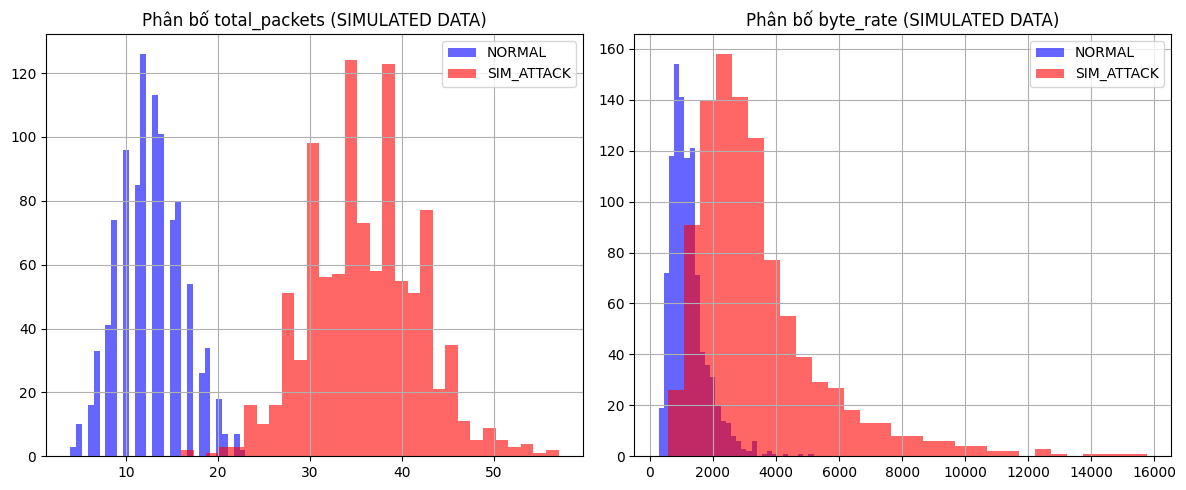

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Đọc dữ liệu mô phỏng
df = pd.read_csv("synthetic_ids.csv") # Đảm bảo file đã được upload lên Colab

# Bước 1: Kiểm tra số dòng/cột và missing value (NaN/Inf)
print("--- BƯỚC 1: THÔNG TIN DỮ LIỆU ---")
print(df.info())

# Bước 2: Kiểm tra số mẫu mỗi lớp
print("\n--- BƯỚC 2: SỐ MẪU MỖI LỚP ---")
print(df["label"].value_counts())

# Bước 3: Tính min/median/mean/max cho 4 feature
print("\n--- BƯỚC 3: THỐNG KÊ MÔ TẢ (SIMULATED DATA) ---")
print(df.groupby("label")[["duration_s", "total_packets", "byte_rate", "dst_port"]].describe())

# Bước 4 & 5: Vẽ histogram total_packets và byte_rate (Ghi rõ phân bố mô phỏng)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df[df['label'] == 'NORMAL']['total_packets'].hist(alpha=0.6, label='NORMAL', bins=30, color='blue')
df[df['label'] == 'SIM_ATTACK']['total_packets'].hist(alpha=0.6, label='SIM_ATTACK', bins=30, color='red')
plt.title('Phân bố total_packets (SIMULATED DATA)')
plt.legend()

plt.subplot(1, 2, 2)
df[df['label'] == 'NORMAL']['byte_rate'].hist(alpha=0.6, label='NORMAL', bins=30, color='blue')
df[df['label'] == 'SIM_ATTACK']['byte_rate'].hist(alpha=0.6, label='SIM_ATTACK', bins=30, color='red')
plt.title('Phân bố byte_rate (SIMULATED DATA)')
plt.legend()

plt.tight_layout()
plt.show()

# GD2: HUẤN LUYỆN VÀ ĐÓNG GÓI MÔ HÌNH

## Mục 8. Bước 4. Chia synthetic data thành 2 tệp train/test

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Đọc dữ liệu từ thư mục data
df = pd.read_csv("synthetic_ids.csv")

# 2. Khai báo 10 features khớp chính xác với feature_set.yaml
FEATURES = [
    "duration_s", "total_packets", "total_bytes",
    "src_packet_rate", "dst_packet_rate", "byte_rate",
    "mean_packet_bytes", "packet_ratio", "byte_ratio", "dst_port"
]

X = df[FEATURES]
y = df["label"]

# 3. Chia tập Train/Test (Tỷ lệ 75/25)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("--- KẾT QUẢ CHIA TẬP DỮ LIỆU ---")
print(f"Kích thước tập Train (X_train): {X_train.shape}")
print(f"Kích thước tập Test (X_test): {X_test.shape}")

--- KẾT QUẢ CHIA TẬP DỮ LIỆU ---
Kích thước tập Train (X_train): (1500, 10)
Kích thước tập Test (X_test): (500, 10)


## Mục 9. Lab 4.2.  Logistic Regression và xuất ra kết quả Confusion Matrix
#### Nhận xét:
*   Trong tổng số 500 mẫu của tập Test (gồm 250 NORMAL và 250 SIM_ATTACK), mô hình đã phân loại xuất sắc khi chỉ đoán sai đúng 3 mẫu. Cụ thể, có 2 luồng NORMAL bị nhận diện nhầm thành tấn công (False Positive) và 1 luồng SIM_ATTACK lọt lưới bị nhận diện là bình thường (False Negative). 497 mẫu còn lại đều chính xác tuyệt đối
*   Phản ảnh đúng bản chất dữ liệu đầu vào. Bởi vì với dữ liệu mô phỏng cố tình phân tách rõ rệt, thuật toán Logistic Regression rất dễ tìm ra ranh giới phân loại.

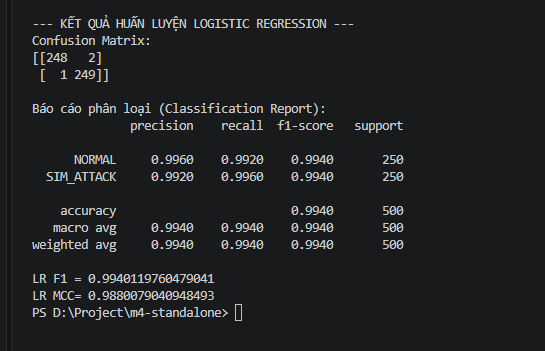



## Mục 10. Lab 4.3 - Random Forest và so sánh giữa 2 thuật toán

### Random Forest:
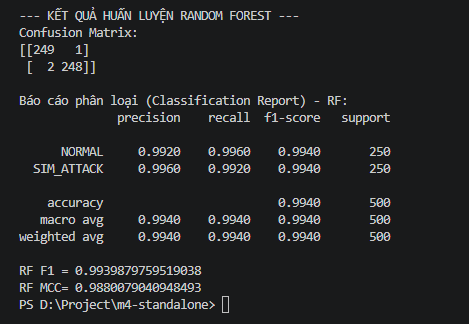

### So sánh hiệu năng hai thuật toán (SIMULATED DATA)
*(Lưu ý: Chỉ số Inference Latency sẽ được đo lường thực tế qua dịch vụ API ở Lab 4.7)*

| Chỉ số (Metrics) | Logistic Regression | Random Forest |
| :--- | :--- | :--- |
| **Accuracy** | 0.9940 | 0.9940 |
| **Precision** (SIM_ATTACK)| 0.9920 | 0.9960 |
| **Recall** (SIM_ATTACK) | 0.9960 | 0.9920 |
| **F1-Score** (SIM_ATTACK) | 0.99401 | 0.99398 |
| **MCC** | 0.9880 | 0.9880 |

**Nhận xét:**
Cả hai thuật toán đều có các chỉ số phân loại gần như tuyệt đối (tiệm cận 1.0) do đang học trên bộ dữ liệu mô phỏng được cố tình phân tách rõ ràng. Việc lựa chọn mô hình tốt nhất không nên chỉ dựa vào Accuracy mà còn phụ thuộc vào thời gian suy luận (Inference Latency) khi chạy API thực tế.



## Mục 11. Bước 5. Lưu model artifact

#### Xuất hiện 2 mã băm SHA256
*   model.joblib: 374c2828ecb4f1a3882d9c1c0983e7452c13722bce4170bfcb3b3504806a0002
*  metadata.json: 2cc271cb6a8845720e375699610d147915d2b195c70eabea30fdcf800d4f4484



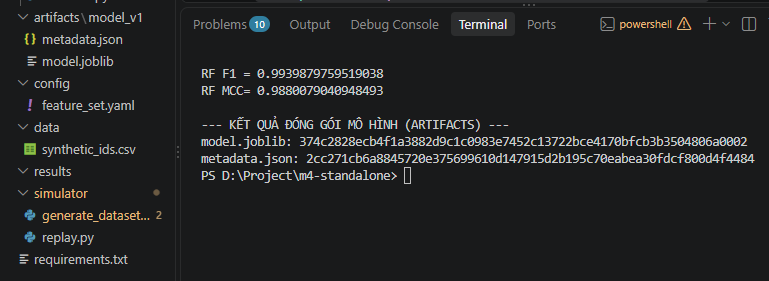

## Mục 12. Lab 4.4. Kiểm tra lưu/ nạp Model
#### Bài test Reload thành công (PASS), xác nhận kết quả dự đoán của model nạp lại từ ổ cứng giống 100% so với model ban đầu

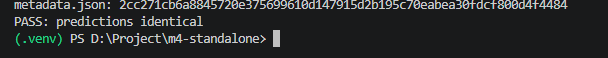

# GD3. TRIỂN KHAI API VÀ CHẠY MÔ PHỎNG

## Mục 13. Bước 6. Tạo FeatureVector giả lập tương thích M3
Định nghĩa cấu trúc bản tin JSON `FeatureVector` làm hợp đồng dữ liệu (Data Contract) chuẩn giữa bộ sinh dữ liệu (Simulator/M3) và dịch vụ suy luận (Inference API):

```json
{
 "flow_id": "sim-000001",
 "feature_set_version": "zone05_flow_v1:1.0.0",
 "features": {
  "duration_s": 0.84,
  "total_packets": 18,
  "total_bytes": 9320,
  "src_packet_rate": 12.4,
  "dst_packet_rate": 9.0,
  "byte_rate": 11095.2,
  "mean_packet_bytes": 517.8,
  "packet_ratio": 1.38,
  "byte_ratio": 1.21,
  "dst_port": 443
 },
 "source": "simulator",
 "timestamp": "2026-09-30T13:30:16Z"
}

## Mục 14. Bước 7: Xây dựng Input Validator
* **Đầu vào:** Bản tin JSON `FeatureVector` (`fv`) và siêu dữ liệu `metadata.json` (`meta`).
* **Đầu ra:** Mảng số thực `numpy.ndarray` kích thước `(1, 10)` nếu hợp lệ, hoặc kích hoạt ngoại lệ `ValueError` nếu vi phạm hợp đồng dữ liệu (sai version, thiếu trường, chứa NaN/Inf, hoặc `dst_port` ngoài khoảng 0..65535).

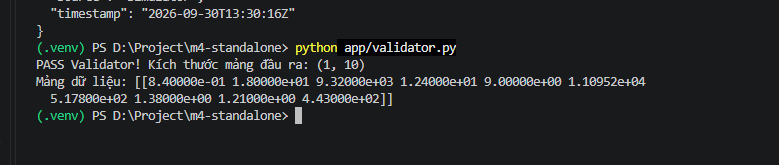

## Mục 15. Bước 8: Xây dựng Inference Service độc lập
* **Đầu vào:** Tệp `model.joblib`, `metadata.json` từ `artifacts/model_v1/` và hàm `validate` từ `app/validator.py`.
* **Đầu ra:** Dịch vụ FastAPI khởi chạy qua `uvicorn` tại địa chỉ `http://127.0.0.1:8004` với 3 endpoints: `/api/v1/health`, `/api/v1/model/info`, và `/api/v1/predict`.
* **Cài đặt dịch vụ API và khởi động dịch vụ tại Terminal 1: Dịch vụ đã được bật thành công**
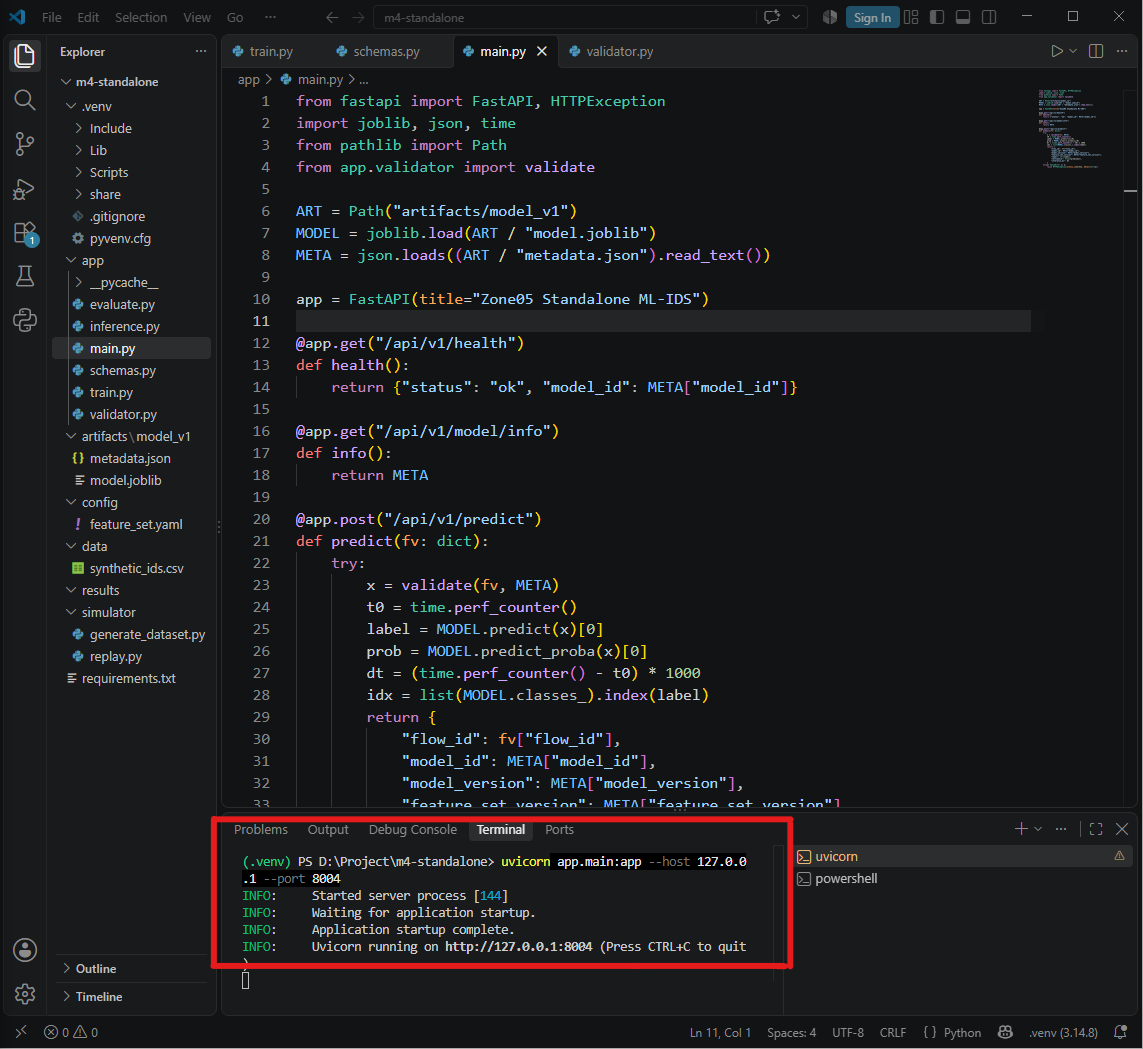

* **Kiểm tra trạng thái hoạt động của API tại Terminal 2: Thông báo dịch vụ suy luận đã sẵn sàng**
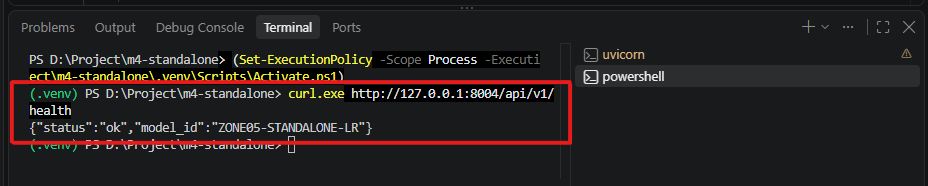

## Mục 16. Lab 4.5 - FeatureVector Replay thời gian gần thực

* **Đầu vào:** 50 bản tin JSON `FeatureVector` (`sim-000001` đến `sim-000050`) trích xuất từ `data/synthetic_ids.csv` lưu vào `data/replay.jsonl`.
* **Thực hiện:** Gửi tuần tự từng vector vào endpoint `http://127.0.0.1:8004/api/v1/predict` với tốc độ 1 vector/giây (`simulator/replay.py`).
* **Đầu ra & Đánh giá:**
  * Thu được tệp `results/predictions.jsonl` chứa đủ 50 kết quả dự đoán.
  * **Kết quả:** **PASS** (50 input tạo đủ 50 response `HTTP 200 OK`, bảo toàn 100% `flow_id`).               
______________________
*MÔ TẢ CHI TIẾT LUỒNG THỰC HIỆN:*
* Tại cửa sổ Powershell (Đóng vai trò Client/ Bộ giả lập nguồn mạng - `replay.py` ):
  * Kịch bản lấy 50 dòng dữ liệu từ tệp data/synthetic_ids.csv đã tạo ở Giai đoạn 1, nhưng cất phần nhãn đáp án (label) đi và chỉ đóng gói 10 thông số kỹ thuật vào bản tin FeatureVector
  * Kịch bản lấy 50 dòng dữ liệu từ tệp data/synthetic_ids.csv đã tạo ở Giai đoạn 1, nhưng cất phần nhãn đáp án (label) đi và chỉ đóng gói 10 thông số kỹ thuật vào bản tin FeatureVector

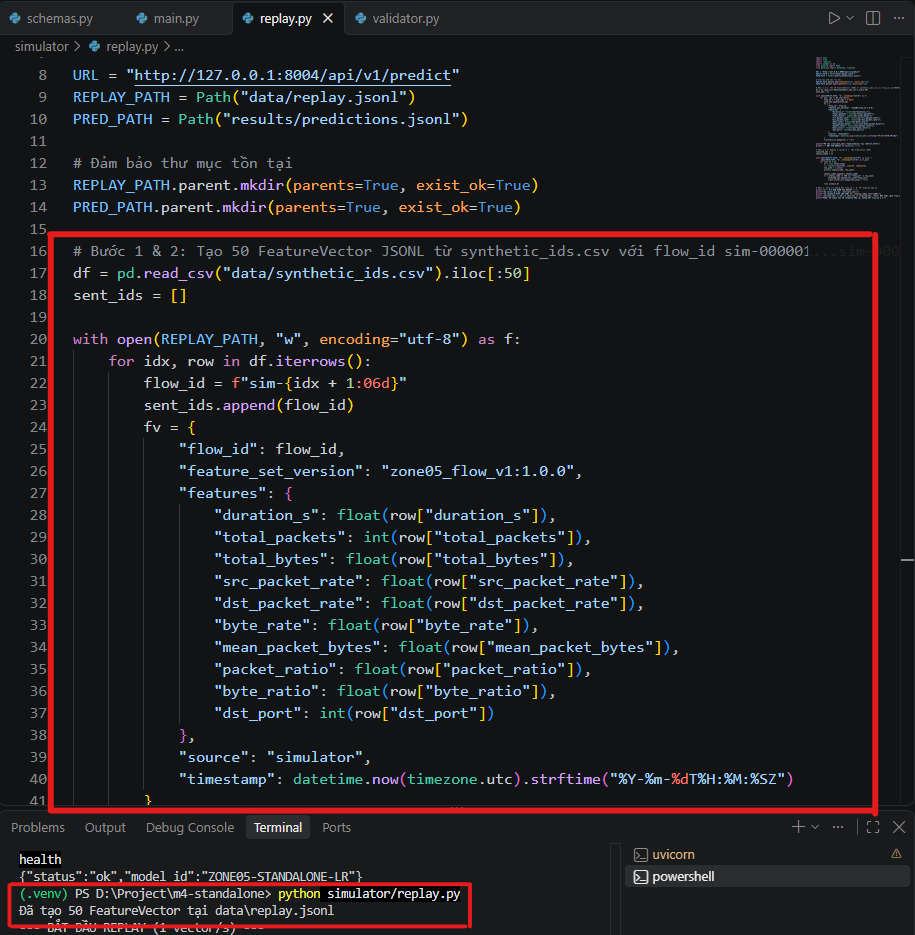

* Tại cửa sổ univcorn (Đóng vai trò Server/ Dịch vụ AI - `main.py`):
  * Ngay khi khởi động, uvicorn nạp sẵn `model.joblib` vào `metadata.json` (kết quả sau khi cho máy học) vào bộ nhớ
  * Khi nhận được từng luồng mạng từ powershell gửi sang, uvicorn thưc hiện 3 việc:
    * Đưa qua **Validator** kiểm tra xem gói tin có hợp lệ không
    * Đưa qua **Pipeline** (StandardScaler + LogisticRegression) để chuẩn hóa và phán đoán xem luồng đó là *NORMAL* hay *SIM_ATTACK* , tính toán confidence và đo inference_ms
  * Trên **Uvicorn Terminal**: Ghi nhận dịch vụ FastAPI đã tiếp nhận từng bản tin FeatureVector gửi tới cổng /api/v1/predict, kiểm tra hợp lệ và trả về kết quả thành công với mã trạng thái chuẩn 200 OK

 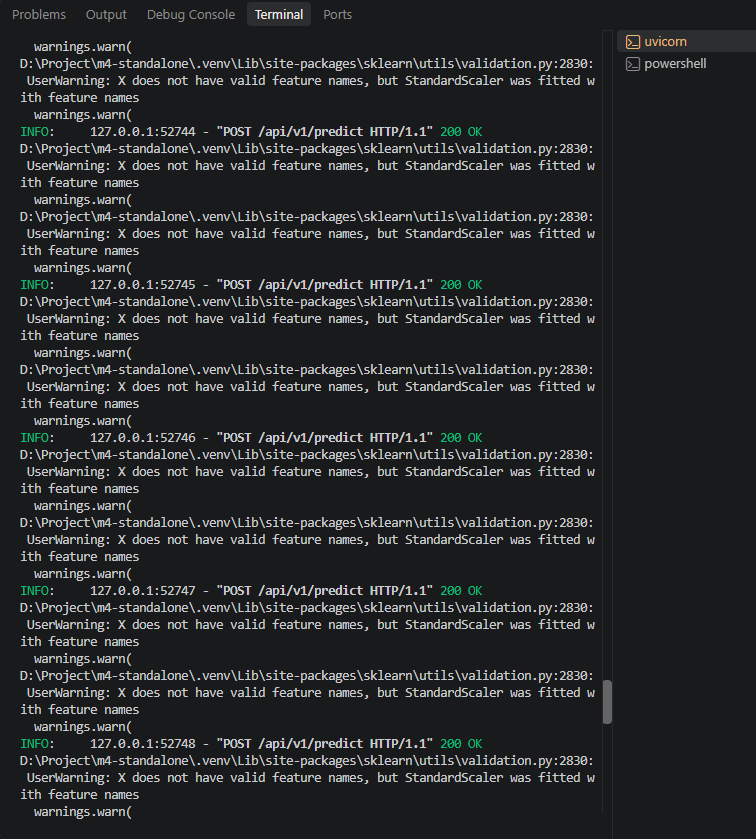

  * Quay lại cửa sổ powershell **(nhận kết quả và lưu trữ)**:
    * Nhận được phản hồi từ uvicorn, cửa sổ powershell in kết quả đó ra màn hình (gồm mã flow_id, nhãn phát hiện label, độ tin cậy confidence và thời gian xử lý inference_ms), đồng thời ghi vào tệp `results/predictions.jsonl`

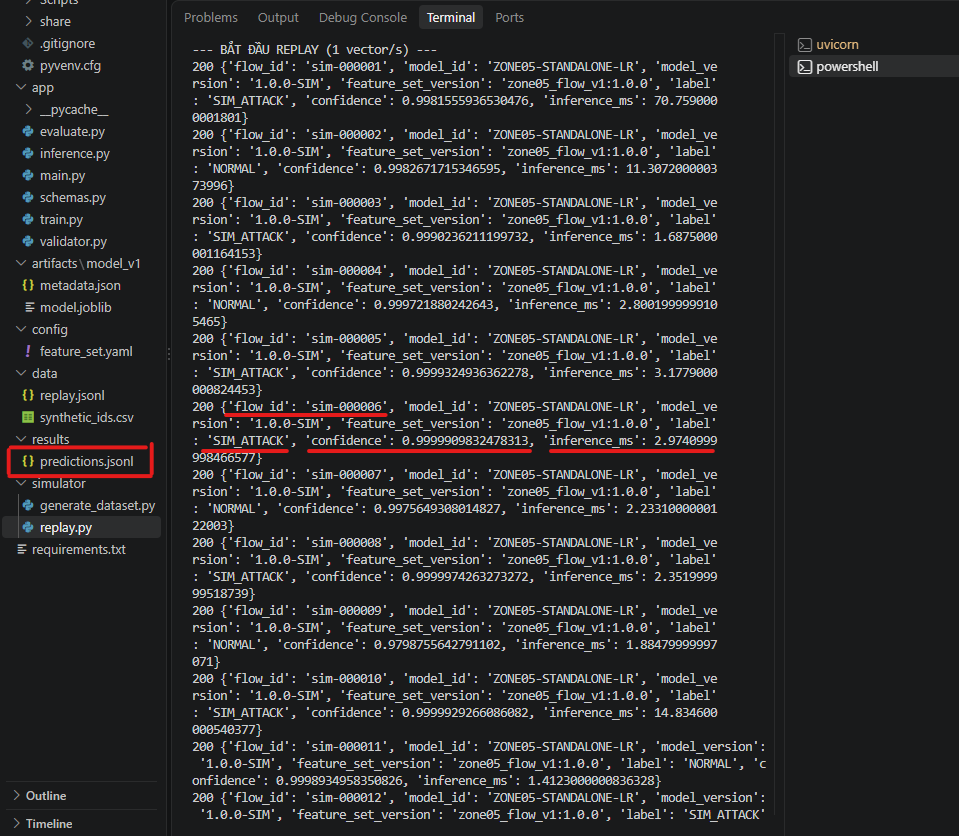


# GD4. Kiểm thử lỗi và đánh giá

## Mục 17. Lab 4.6: Kiểm thử lỗi đầu vào (Fault Test E1 - E5)
* **Mục tiêu:** Đảm bảo các bản tin vi phạm hợp đồng dữ liệu bị từ chối (Reject / HTTP 422), không sinh ra Prediction giả và không làm dừng dịch vụ Inference API.
* **Bảng kết quả thực nghiệm:**
  * Các ca lỗi E1 (sai phiên bản), E2 (thiếu trường total_bytes) và E4 (dst_port > 65535) đều bị dịch vụ FastAPI chặn lại và trả về mã lỗi chuẩn HTTP 422 kèm nguyên nhân chi tiết.
  * Ca lỗi E3 (chứa giá trị NaN/Inf) đã bị hàm validate() từ chối chính xác qua unit test với thông báo NON_FINITE_FEATURE.
  * Ca hợp lệ E5 ngay sau đó vẫn nhận được phản hồi HTTP 200 (label: SIM_ATTACK, confidence: 0.9997), chứng minh dịch vụ suy luận hoàn toàn không bị sập khi gặp dữ liệu lỗi

| Ca kiểm thử | Thay đổi đầu vào | Kết quả mong đợi | Kết quả thực tế | Đánh giá |
| :--- | :--- | :--- | :--- | :--- |
| **E1** | Sai `feature_set_version` | HTTP 422 | HTTP 422 (`FEATURE_SET_VERSION_MISMATCH`) | **PASS** |
| **E2** | Thiếu `total_bytes` | HTTP 422 | HTTP 422 (`MISSING_FEATURES`) | **PASS** |
| **E3** | Chứa `NaN`/`Inf` (Unit test) | Reject | Reject (`NON_FINITE_FEATURE`) | **PASS** |
| **E4** | `dst_port = 70000` (> 65535) | Reject | HTTP 422 (`INVALID_DST_PORT`) | **PASS** |
| **E5** | Vector hợp lệ (`sim-000001`) | HTTP 200 | HTTP 200 (Trả về Prediction hợp lệ) | **PASS** |

* **Minh chứng thực thi trên VS Code:**
  * Phần máy Client:
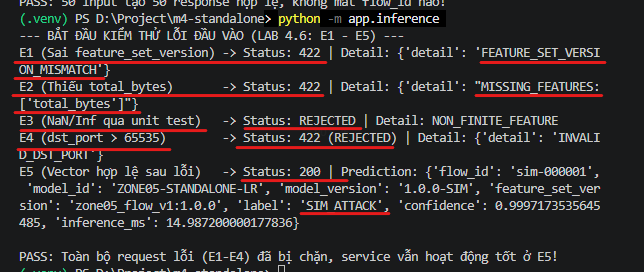
  * Phần máy Server
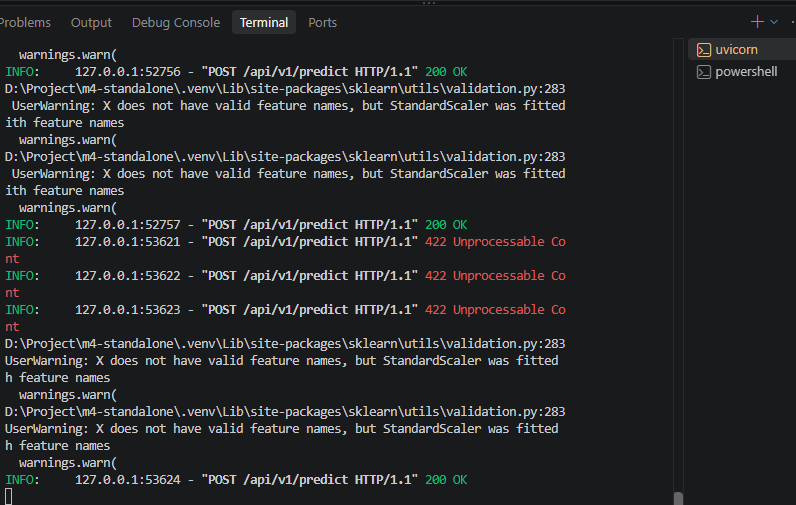

## Mục 18. Lab 4.7: Đo Inference Latency và Throughput
* **Cấu hình môi trường thử nghiệm:**
  * **CPU / OS:** Windows 10 (AMD64)
  * **Processor**: Intel64 Family 6 Model 140 Stepping 1, GenuineIntel
  * **RAM**: 8GB (Dual-channel) DDR4 2666MT/s
  * **Python version:** 3.14.8
  * **Model version:** `1.0.0-SIM` (`ZONE05-STANDALONE-LR`)
  * **Số lượng request ($N$):** 200 requests (`N_success = 200`)
* **Kết quả đo lường hiệu năng:**
  * **Client Latency (HTTP + Validation + Inference):**
    * `mean_ms`: 18.5968 ms
    * `median_ms`: 16.5946 ms
    * `p95_ms`: 31.2639 ms
  * **Service Model Inference (`inference_ms` trung bình):** 2.5084 ms
  * **Throughput**: 53.71 requests/sec
* **Minh chứng thực thi trên VS Code:**

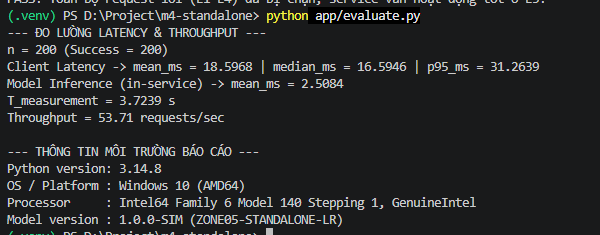

## Mục 19. Lab 4.8: Đánh giá tổng hợp trên Test Set có nhãn (SIMULATED DATA)
* **Thông tin truy vết (Traceability):**
  * `data_source`: `synthetic_ids.csv` (Tập kiểm thử `X_test` gồm 500 mẫu độc lập, chưa dùng để fit mô hình)
  * `model_id` / `model_version`: `ZONE05-STANDALONE-LR` / `1.0.0-SIM`
  * `feature_set_version`: `zone05_flow_v1:1.0.0`
* **Bảng kết quả đánh giá (Evaluation Metrics):**

| Chỉ số (Metric) | Giá trị trên Test Set (`n = 500`) |
| :--- | :--- |
| **Confusion Matrix** (`NORMAL`, `SIM_ATTACK`) | `[[248, 2], [1, 249]]` |
| **Accuracy** | `0.9940` |
| **Precision** (`pos_label="SIM_ATTACK"`) | `0.9920` |
| **Recall** (`pos_label="SIM_ATTACK"`) | `0.9960` |
| **F1-score** (`pos_label="SIM_ATTACK"`) | `0.9940` |
| **MCC (Matthews Correlation Coefficient)** | `0.9880` |

* **Nhận xét:** Mô hình đạt độ chính xác cao trên tập kiểm thử độc lập do dữ liệu mô phỏng được thiết kế phân tách một phần giữa hai profile `NORMAL` và `SIM_ATTACK`. Kết quả này xác nhận pipeline học máy và đóng gói artifact hoạt động chính xác, không đại diện cho hiệu năng IDS trên lưu lượng mạng thực tế.
* **Minh chứng thực thi trên VS Code:**
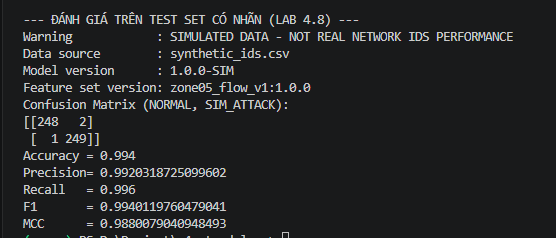

# **PHIẾU NGHIỆM THU KẾT QUẢ**
**NOTE:** SIMULATED DATA - NOT REAL NETWORK IDS PERFORMANCE

| Nội dung | PASS/FAIL | Evidence (Minh chứng đạt được) |
| :--- | :---: | :--- |
| **Environment** | **PASS** | Đã khởi tạo `.venv`, cài đặt đủ thư viện và tạo cấu trúc thư mục `m4-standalone/` (Mục 4). |
| **Synthetic dataset** | **PASS** | Đã sinh `data/synthetic_ids.csv` gồm 2000 mẫu cân bằng (1000 `NORMAL`, 1000 `SIM_ATTACK`) với `seed=42` (Mục 6). |
| **EDA** | **PASS** | Đã kiểm tra không có `NaN`/`Inf`, thống kê `describe()` 4 đặc trưng và vẽ biểu đồ Histogram tách lớp (Lab 4.1). |
| **Train/test split** | **PASS** | Chia `X_train` (1500 mẫu) và `X_test` (500 mẫu) theo tỷ lệ 75/25 (`stratify=y`), chỉ fit `StandardScaler` trên `X_train` (Mục 8). |
| **LR** | **PASS** | Pipeline Logistic Regression đạt Accuracy = `0.9940`, F1 = `0.9940`, MCC = `0.9880`, Confusion Matrix `[[248, 2], [1, 249]]` (Lab 4.2). |
| **RF** | **PASS** | Random Forest chạy trên cùng tập split đạt Accuracy = `0.9940`, F1 = `0.9940`, MCC = `0.9880`, Confusion Matrix `[[249, 1], [2, 248]]` (Lab 4.3). |
| **Artifact** | **PASS** | Đã xuất `model.joblib`, `metadata.json` kèm mã băm SHA256 và kiểm thử reload khớp 100% trên 20 mẫu (Mục 11 & Lab 4.4). |
| **Replay** | **PASS** | Đã phát lại 50 vector (`sim-000001`..`sim-000050`) tốc độ 1 vector/s vào cổng 8004, nhận đủ 50 HTTP 200 tại `results/predictions.jsonl` (Lab 4.5). |
| **Input faults** | **PASS** | Kiểm thử E1–E5 (Lab 4.6):<br><br>- Chặn lỗi E1, E2, E4 (HTTP 422) và E3 (`NON_FINITE_FEATURE`)<br><br>- Service không dừng và trả HTTP 200 ở E5. |
| **Latency** | **PASS** | Đo trên 200 requests gửi vào API (Lab 4.7):<br> <br>- `mean_ms`: `18.5968 ms`<br> <br>- `median_ms`: `16.5946 ms`<br> <br>- `p95_ms`: `31.2639 ms`<br> <br>- Model `inference_ms` trung bình: `2.5084 ms` |
| **Throughput** | **PASS** | Đạt `53.71 requests/sec` (`200 requests / 3.7239s`) trên Windows 10 AMD64, CPU Intel64 Family 6 Model 140, Python 3.14.8, model `1.0.0-SIM` (Lab 4.7). |
| **F1/MCC** | **PASS** | Đánh giá trên tập test có nhãn `synthetic_ids.csv` (Lab 4.8):<br><br>- Confusion Matrix: `[[248, 2], [1, 249]]`<br><br>- Accuracy: `0.9940` \| Precision: `0.9920` \| Recall: `0.9960`<br><br>- F1: `0.9940` \| MCC: `0.9880` |
| **Dashboard/Report** | **PASS** | Sổ tay báo cáo `report.ipynb` đầy đủ minh chứng và gắn cảnh báo `SIMULATED DATA - NOT REAL NETWORK IDS PERFORMANCE`. |